/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_41295/3346744243.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


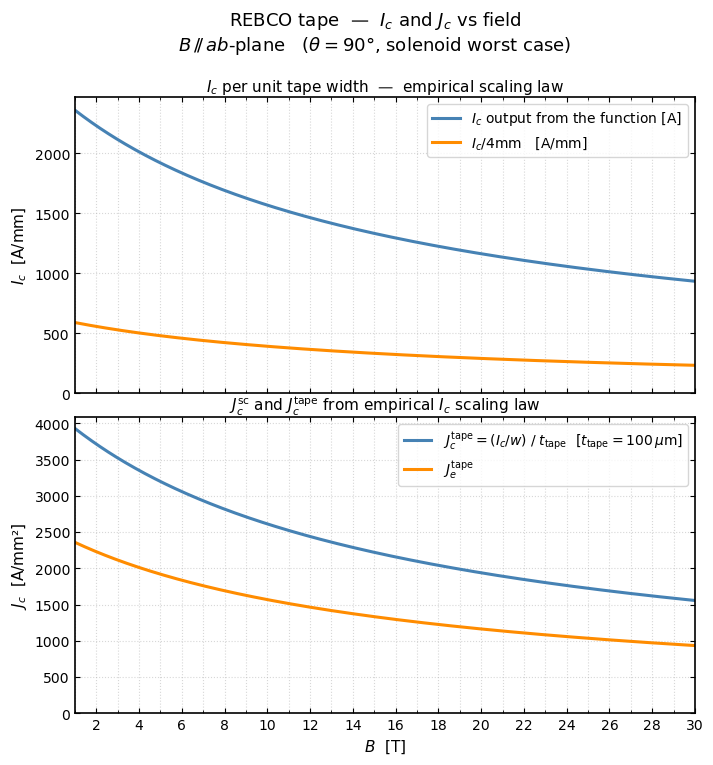

Saved → Ic_Jc_tape_sc_vs_B.png


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Plot Ic_tape [A/mm] and Jc_tape / Jc_sc [A/mm²] vs B (1 T to 20 T)
# Uses the standalone Ic_tape function (returns A/m per unit tape width).
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

mu0 = 4.0e-7 * np.pi

# ─────────────────────────────────────────────────────────────────────────────
# Ic_tape scaling law
# ─────────────────────────────────────────────────────────────────────────────

def Ic_tape(b, theta):
    """
    Critical current per unit tape width [A].

    Parameters:
        b     : field magnitude [T]  — float or np.ndarray
        theta : field angle [rad] w.r.t. c-axis
                0    = B // c-axis
                pi/2 = B // ab-plane  (solenoid worst case)

    Returns:
        Ic per unit tape width [A]
    """
    k0     = 8870
    k1     = 18500
    alpha0 = 1.3
    alpha1 = 0.809
    beta0  = 13.8
    beta1  = 13.8
    phi1   = -0.180 * np.pi / 180
    c1     = 2.15

    omega = c1 * (b + (1 / c1)**(5 / 3))**(3 / 5)

    return (
        k0 / (b + beta0)**alpha0
        + k1 / (b + beta1)**alpha1
        * (omega**2 * np.cos(theta - phi1)**2
           + np.sin(theta - phi1)**2)**(-0.5)
    )

def solenoid_field_center(ri: float, rf: float,
                          j: float,
                          l: float ):
    """
    Central axial field  [T] — exact analytical integral of Biot-Savart
    for a finite-length thick-walled solenoid.

    Parameters
    ----------
    ri : inner radius [m]
    rf : outer radius [m]
    j  : winding engineering current density Je [A/m²]
    l  : solenoid length [m]

    Returns
    -------
    b0 : central field [T]
    """
    j_arr = np.asarray(j)

    if ri >= rf:
        raise ValueError("ri must be < rf.")
    if l <= 0:
        raise ValueError("l must be positive.")
    if np.all(j_arr == 0):
        raise ValueError("j must be non-zero.")

    zp =  l / 2.0
    zm = -l / 2.0

    def log_term(z):
        return z * np.log(
            (np.sqrt(rf**2 + z**2) + rf) /
            (np.sqrt(ri**2 + z**2) + ri)
        )

    return (mu0 * j_arr / 2.0) * (log_term(zp) - log_term(zm))

def hoop_stress(ri: float, rf: float,
                j: float,
                l: float ):
    """
    Peak hoop (circumferential) stress  [Pa]  and central field  [T]
    using the magnetic-pressure thin-shell approximation.

        sigma_hoop = (b0² / 2µ0) × (ri / th)

    Parameters
    ----------
    ri : inner radius [m]
    rf : outer radius [m]
    j  : winding engineering current density Je [A/m²]
    l  : solenoid length [m]

    Returns
    -------
    sigma : hoop stress [Pa]
    b0    : central field [T]
    """
    j_arr = np.asarray(j)

    if ri >= rf or l <= 0 or np.all(j_arr == 0):
        raise ValueError("Invalid parameters.")
    th = rf - ri
    if th <= 0:
        raise ValueError("th must be positive.")

    b0    = solenoid_field_center(ri, rf, j_arr, l)
    sigma = (b0**2 / (2.0 * mu0)) * (ri / th)

    return sigma, b0
# ─────────────────────────────────────────────────────────────────────────────
# Tape geometry
# ─────────────────────────────────────────────────────────────────────────────
t_tape_mm = 0.15     # Total tape thickness [mm]
t_sc_mm   = 0.002   # SC layer thickness   [mm]  (2 µm)
w_tape_mm = 4.0     # Tape width           [mm]

theta_solenoid = np.pi / 2    # B // ab-plane — worst case
# theta_solenoid = 0

# ─────────────────────────────────────────────────────────────────────────────
# Field array
# ─────────────────────────────────────────────────────────────────────────────
b_arr = np.linspace(1.0, 40, 500)   # [T]

# ─────────────────────────────────────────────────────────────────────────────
# Compute curves  — Ic_tape returns [A] per unit tape width
# ─────────────────────────────────────────────────────────────────────────────
ic         = Ic_tape(b_arr, theta_solenoid)   # [A] for 4 mm wide tape
ic_w       = ic / w_tape_mm                   # [A/mm]  per mm of tape width

jc_tape_mm2 = ic_w / t_tape_mm               # [A/mm²]  full tape cross-section
je_40       = jc_tape_mm2 * 0.6      # [A/mm²]  engineering Jc with 40% fill factor

sigma , b0 = hoop_stress(ri=0.05, rf=0.1, j=je_40*1e6, l=0.2)  # [Pa]  hoop stress at B = 50 T

# ─────────────────────────────────────────────────────────────────────────────
# Figure  —  2 panels, shared x-axis
# ─────────────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8, 8),
    sharex=True,
    gridspec_kw={"hspace": 0.08},
)

fig.suptitle(
    r"REBCO tape  —  $I_c$ and $J_c$ vs field"
    "\n"
    r"$B \,/\!/\, ab$-plane   ($\theta = 90°$, solenoid worst case)",
    fontsize=13, y=0.99,
)

# ── Panel 1 : Ic per unit width [A/mm] ───────────────────────────────────────
ax1.plot(b_arr, ic,   color="steelblue",  lw=2.2,
         label=r"$I_c$ output from the function [A]")
ax1.plot(b_arr, ic_w, color="darkorange", lw=2.2,
         label=r"$I_c$/4mm   [A/mm]")

ax1.set_ylabel(r"$I_c$  [A/mm]", fontsize=11)
ax1.set_ylim(bottom=0)
ax1.legend(fontsize=10, loc="upper right")
ax1.grid(True, which="both", ls=":", alpha=0.5)
ax1.set_title(
    r"$I_c$ per unit tape width  —  empirical scaling law",
    fontsize=11, pad=4,
)

# ── Panel 2 : Jc_tape and Je_40 [A/mm²] ─────────────────────────────────────
ax2.plot(b_arr, jc_tape_mm2, color="steelblue",  lw=2.2,
         label=r"$J_c^{\rm tape} = (I_c/w) \;/\; t_{\rm tape}$  "
               r"[$t_{\rm tape} = 100\,\mu$m]")
ax2.plot(b_arr, je_40,       color="darkorange", lw=2.2,
         label=r"$J_e^{\rm tape}$")

ax2.set_xlabel(r"$B$  [T]", fontsize=11)
ax2.set_ylabel(r"$J_c$  [A/mm²]", fontsize=11)
ax2.set_ylim(bottom=0)
ax2.legend(fontsize=10, loc="upper right")
ax2.grid(True, which="both", ls=":", alpha=0.5)
ax2.set_title(
    r"$J_c^{\rm sc}$ and $J_c^{\rm tape}$ from empirical $I_c$ scaling law",
    fontsize=11, pad=4,
)

# ── Shared x-axis formatting ──────────────────────────────────────────────────
ax2.set_xlim(1, 30)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax2.xaxis.set_minor_locator(ticker.MultipleLocator(1))

for ax in (ax1, ax2):
    ax.tick_params(
        which="both",
        top=True, bottom=True, left=True, right=True,
        direction="in", labelsize=10,
    )
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

plt.tight_layout()
plt.savefig("Ic_Jc_tape_sc_vs_B.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → Ic_Jc_tape_sc_vs_B.png")
